Data exploration notebook

In [37]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import pandas as pd
import random
import numpy as np
import math


1. Data loading, checking and illisble files

In [38]:
# Importing the relevant data
data_path: Path = Path("/home/candidate/maia_261_jl/data/raw")

raw_data: pd.DataFrame = pd.read_csv(data_path / "data_info.csv", header=0, index_col=0)
raw_images_path: Path = data_path / "check-X-ray"

# Checking the data rows and columns IDs
print(f"CSV header :\n{raw_data.head()}\n")

print(f"CSV number of samples : {raw_data.shape[0]}")
all_images: list[Path] = list(raw_images_path.glob("*"))
print(f"Number of images in the dataset : {len(all_images)}\n")

for i, column in enumerate(raw_data.columns):
    print(f"Column {i}: {column}")

# Checking if there is no corrupted data
invalid_images: list[Path] = []

for image_path in all_images:
    try:
        with Image.open(image_path) as im:
            im.verify()
    except (UnidentifiedImageError, OSError) as e:
        invalid_images.append(image_path)
        print(f"File {image_path.name} could not be opened: {e}")
print(f"\nNumber of invalid files : {len(invalid_images)} over {len(all_images)} files\n")


CSV header :
  filename  label
0   0.tiff      0
1   1.tiff      0
2   2.tiff      0
3   3.tiff      0
4   4.tiff      0

CSV number of samples : 624
Number of images in the dataset : 624

Column 0: filename
Column 1: label

Number of invalid files : 0 over 624 files



2. NA-Null values, labels, duplication checkings

In [39]:
# Checking if there are NA-Null values 
print(f"Number of NA values in the CSV : {raw_data.isna().sum().sum()}")
print(f"Number of Null values in the CSV : {raw_data.isnull().sum().sum()}\n")

# Checking the different labels and if there is duplication in the files
print(f"Different label values : {raw_data['label'].unique()}\n")
print(f"Number of unique files : {raw_data['filename'].nunique()} over {len(raw_data['filename'])} files")

# No file cleaning since all the validity checks were completed


Number of NA values in the CSV : 0
Number of Null values in the CSV : 0

Different label values : [0 1 2]

Number of unique files : 624 over 624 files


3. Checking if all the samples in the CSV are present in the image set and data leakage

In [40]:
# Check if all the data filenames can be found with the images
filenames_set: set = set(raw_data['filename'])
unavailable_images: list[Path] = []

for image_path in all_images:
    if not image_path.name in filenames_set:
        print(f"File {image_path.name} is not in the images set") 
        unavailable_images.append(image_path)
print(f"Number of images not present in the CSV : {len(unavailable_images)} over {len(all_images)} files")

# Could not evaluate data leakeage (patient radiography found multiple times) since no information is provided 
# on the patient ID 


Number of images not present in the CSV : 0 over 624 files


4. Checking the class imbalance with plots chart and exact samples per categories values

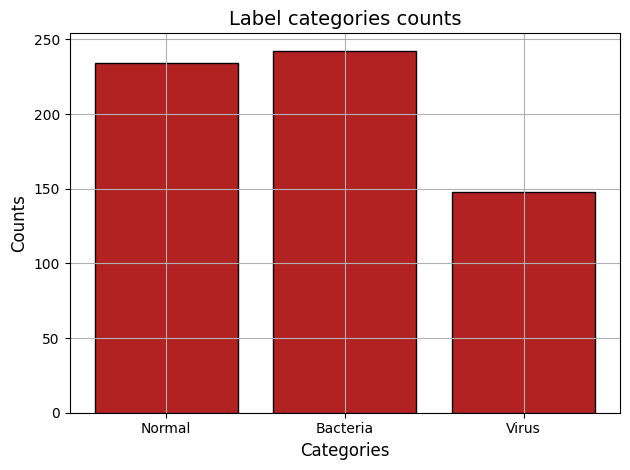

Number of samples per category (0:Normal, 1:Bacteria, 2:Virus) : 
label
1    242
0    234
2    148
Name: count, dtype: int64


In [41]:
# Displaying the plot charts of the classes distribution
label_counts = raw_data['label'].value_counts()
label_charts = plt.bar(label_counts.index, label_counts.values, color='firebrick', edgecolor='black')
plt.title('Label categories counts', fontsize=14)
plt.xlabel('Categories', fontsize=12)
plt.xticks([0, 1, 2], ['Normal', 'Bacteria', 'Virus'])
plt.ylabel('Counts', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Printing the exact values per category
print(f"Number of samples per category (0:Normal, 1:Bacteria, 2:Virus) : \n{raw_data['label'].value_counts()}")


5. Visualizing random images per label category

Number of samples in the normal CSV : 234 - in the original CSV : 234
Number of samples in the bacteria CSV : 242 - in the original CSV : 242
Number of samples in the virus CSV : 148 - in the original CSV : 148



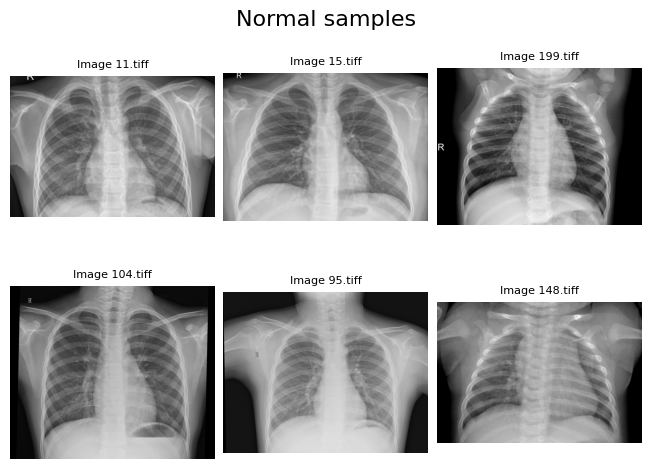

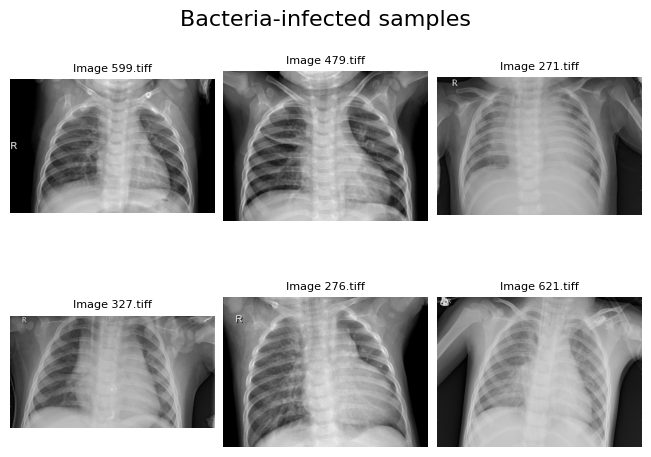

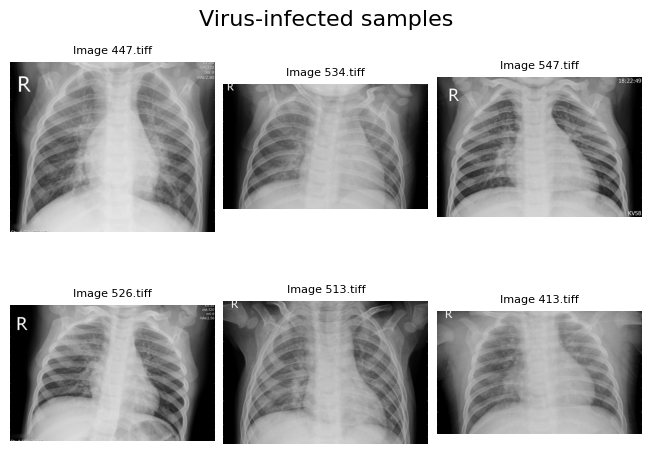

In [42]:
# Displaying some images per category
num_display_samples: int = 6
num_columns: int = 3
num_rows: int = math.ceil(num_display_samples / num_columns)

# Mapping each label category data into csv, to display files within
normal_csv: pd.DataFrame = raw_data[raw_data['label'] == 0].reset_index(drop=True)
bacteria_csv: pd.DataFrame = raw_data[raw_data['label'] == 1].reset_index(drop=True)
virus_csv: pd.DataFrame = raw_data[raw_data['label'] == 2].reset_index(drop=True)
analyzed_csv: list[pd.DataFrame] = [normal_csv, bacteria_csv, virus_csv]

# Checking if the number of samples in the new CSV match the original ones
print(f"Number of samples in the normal CSV : {normal_csv.shape[0]} - in the original CSV : {label_counts[0]}")
print(f"Number of samples in the bacteria CSV : {bacteria_csv.shape[0]} - in the original CSV : {label_counts[1]}")
print(f"Number of samples in the virus CSV : {virus_csv.shape[0]} - in the original CSV : {label_counts[2]}\n")

for i in analyzed_csv:
    figure_name: str = f"Normal samples" if i is normal_csv else \
        (f"Bacteria-infected samples" if i is bacteria_csv  else f"Virus-infected samples")
    display_figure: plt.Figure = plt.figure(layout="constrained")
    display_axes: np.ndarray = display_figure.subplots(nrows=num_rows, ncols=num_columns)
    display_figure.suptitle(figure_name, fontsize=16)

    for j in range(num_display_samples):
        display_sample_idx: int = random.randint(0, i.shape[0] - 1)

        filename: str = i['filename'][display_sample_idx]
        img: Path = raw_images_path / filename

        with Image.open(img) as pil_img:
            ax: plt.Axes = display_axes[
                j // num_columns, 
                j % num_columns
            ]
            ax.imshow(pil_img, cmap='gray')
            ax.set_title(f"Image {filename}", fontsize=8)
            ax.axis("off")
    plt.show()


6. Analyzing images format : RGB, grayscale, dtype, sizes histogram 

In [ ]:
# Checking if images are either at the RGB or grayscale format
 


7. Pixel spacing : histograms, images with and without pixel spacing (60min)

8. Images intensity : min/max, global and per classes histogram (70min)

Conclusions : 